# Redshift-Space Distortion (RSD) Sub-volume Corrections

In standard clustering, Subvolume subsampling severely artificialises the 1-halo spatial term. 
When working with Redshift-Space Distortions (RSD), peculiar velocities drastically stretch this 1-halo clustering along the line of sight (producing the classic "Fingers-of-God" effect). 

This notebook validates the `compute_weighted_rsd_multipoles` algorithm implemented in the module `galform_analysis.analysis.redshift_space_distortions.subvol_weighted_multipoles`.
We apply sub-vol weighting to isolate the expected Monopole ($\xi_0$) and Quadrupole ($\xi_2$), completely bypassing the substantial anisotropic smearing bias artificially introduced by subsampling!

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add the GALFORM python source package
sys.path.append(str(Path("../../src").resolve()))

from galform_analysis.analysis.redshift_space_distortions.subvol_weighted_multipoles import (
    compute_weighted_rsd_multipoles,
)
from galform_analysis.utils.read_galaxies import read_galaxy_arrays
from galform_analysis.config import Cosmology, get_snapshot_redshift

# Default plotting style used across the project notebooks
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Load Real GALFORM Galaxies (Lightweight Notebook Sample)
This section uses real GALFORM outputs (the same source tree used by the SLURM jobs), but only a small subset so it runs interactively.

We build redshift-space positions with:
- box position: $z$
- line-of-sight velocity: $v_z$ (`vzgal`)
- shift: $\Delta s_\parallel \approx v_z \; h / H(z)$ in $h^{-1}\,\mathrm{Mpc}$

Then we compare RSD multipoles for using 1 vs 2 vs 3 subvolumes.

In [4]:
# Data location (same family as SLURM workflows)
BASE_DIR = Path("/cosma5/data/durham/dc-hick2/Galform_Out/L800/lc16")
IZ = 155
BOXSIZE = 542.16
K_TOTAL = 1024

# Lightweight notebook settings
MAX_GAL_PER_SUBVOL = 3000
MHALO_MIN = 1e10
CENTRALS_ONLY = False
IVOLS_FOR_COMPARISON = [0, 1, 2]  # compare m=1,2,3 by taking first m ivols

# Convert z-position to redshift space with vzgal
z_snap = get_snapshot_redshift(f"iz{IZ}")
if z_snap is None:
    z_snap = 0.0

h = Cosmology.h
Ez = np.sqrt(Cosmology.OMEGA_M * (1.0 + z_snap) ** 3 + Cosmology.OMEGA_L)
H_z = 100.0 * h * Ez  # km/s/Mpc

print(f"Using {BASE_DIR}/iz{IZ}")
print(f"Snapshot redshift z={z_snap:.3f}, H(z)={H_z:.2f} km/s/Mpc")


def load_rsd_positions_for_ivols(ivols):
    pos_chunks = []
    label_chunks = []

    for label, ivol in enumerate(ivols):
        arrays, _ = read_galaxy_arrays(
            iz_path=str(BASE_DIR / f"iz{IZ}"),
            ivol=int(ivol),
            fields=["vzgal"],
            include_positions=True,
            include_derived=True,
            centrals_only=CENTRALS_ONLY,
            mhalo_min=MHALO_MIN,
        )

        x = arrays["x"]
        y = arrays["y"]
        z = arrays["z"]
        vz = arrays["vzgal"]

        # Randomly thin to keep the notebook fast and interactive
        n = len(x)
        if n > MAX_GAL_PER_SUBVOL:
            idx = np.random.choice(n, size=MAX_GAL_PER_SUBVOL, replace=False)
            x, y, z, vz = x[idx], y[idx], z[idx], vz[idx]

        ds_par = (vz / H_z) * h  # Mpc/h
        z_rsd = (z + ds_par) % BOXSIZE

        pos = np.column_stack([x, y, z_rsd])
        labels = np.full(pos.shape[0], label, dtype=np.int64)

        pos_chunks.append(pos)
        label_chunks.append(labels)

        print(f"ivol{ivol}: loaded {pos.shape[0]} galaxies")

    gal_pos = np.vstack(pos_chunks)
    gal_labels = np.concatenate(label_chunks)
    return gal_pos, gal_labels

Using /cosma5/data/durham/dc-hick2/Galform_Out/L800/lc16/iz155
Snapshot redshift z=1.496, H(z)=158.41 km/s/Mpc


## 2. Compute RSD Multipoles for 1, 2, and 3 Subvolumes
For each $m \in \{1,2,3\}$, we concatenate the first $m$ subvolumes, compute standard and corrected $\xi(s,\mu)$, and project to:
- monopole $\xi_0(s)$
- quadrupole $\xi_2(s)$

In [5]:
# Corrfunc binning (kept moderate for notebook runtime)
s_bins = np.logspace(-1, 1.4, 18)
mu_max = 1.0
n_mu_bins = 16

results_by_m = {}

for m in [1, 2, 3]:
    ivols = IVOLS_FOR_COMPARISON[:m]
    gal_pos, labels = load_rsd_positions_for_ivols(ivols)

    # Use a moderate random catalogue size for speed
    n_random = max(12000, int(2.5 * gal_pos.shape[0]))
    rand_pos = np.random.uniform(0.0, BOXSIZE, size=(n_random, 3))

    res = compute_weighted_rsd_multipoles(
        galaxy_pos=gal_pos,
        galaxy_labels=labels,
        random_pos=rand_pos,
        s_bins=s_bins,
        mu_max=mu_max,
        n_mu_bins=n_mu_bins,
        k_total=K_TOTAL,
        boxsize=BOXSIZE,
        nthreads=4,
    )

    results_by_m[m] = res
    print(
        f"m={m}: ngal={gal_pos.shape[0]}, nrand={n_random}, "
        f"alpha={res['alpha']:.6f}, beta={res['beta'] if np.isfinite(res['beta']) else np.nan}"
    )

ivol0: loaded 3000 galaxies
m=1: ngal=3000, nrand=12000, alpha=0.000977, beta=nan
ivol0: loaded 3000 galaxies
ivol1: loaded 3000 galaxies
m=2: ngal=6000, nrand=15000, alpha=0.001953, beta=1.998046875
ivol0: loaded 3000 galaxies
ivol1: loaded 3000 galaxies
ivol2: loaded 3000 galaxies
m=3: ngal=9000, nrand=22500, alpha=0.002930, beta=1.49853515625


## 3. RSD Curves By Subvolume Count (CSV Runs)
This section reads the completed RSD CSV jobs and overlays all available $n_{subvol}$ curves.

Layout is split by estimator mode:
- left column: **standard**
- right column: **corrected**

Top row shows monopole and bottom row shows quadrupole, each compared to the full-box standard reference.

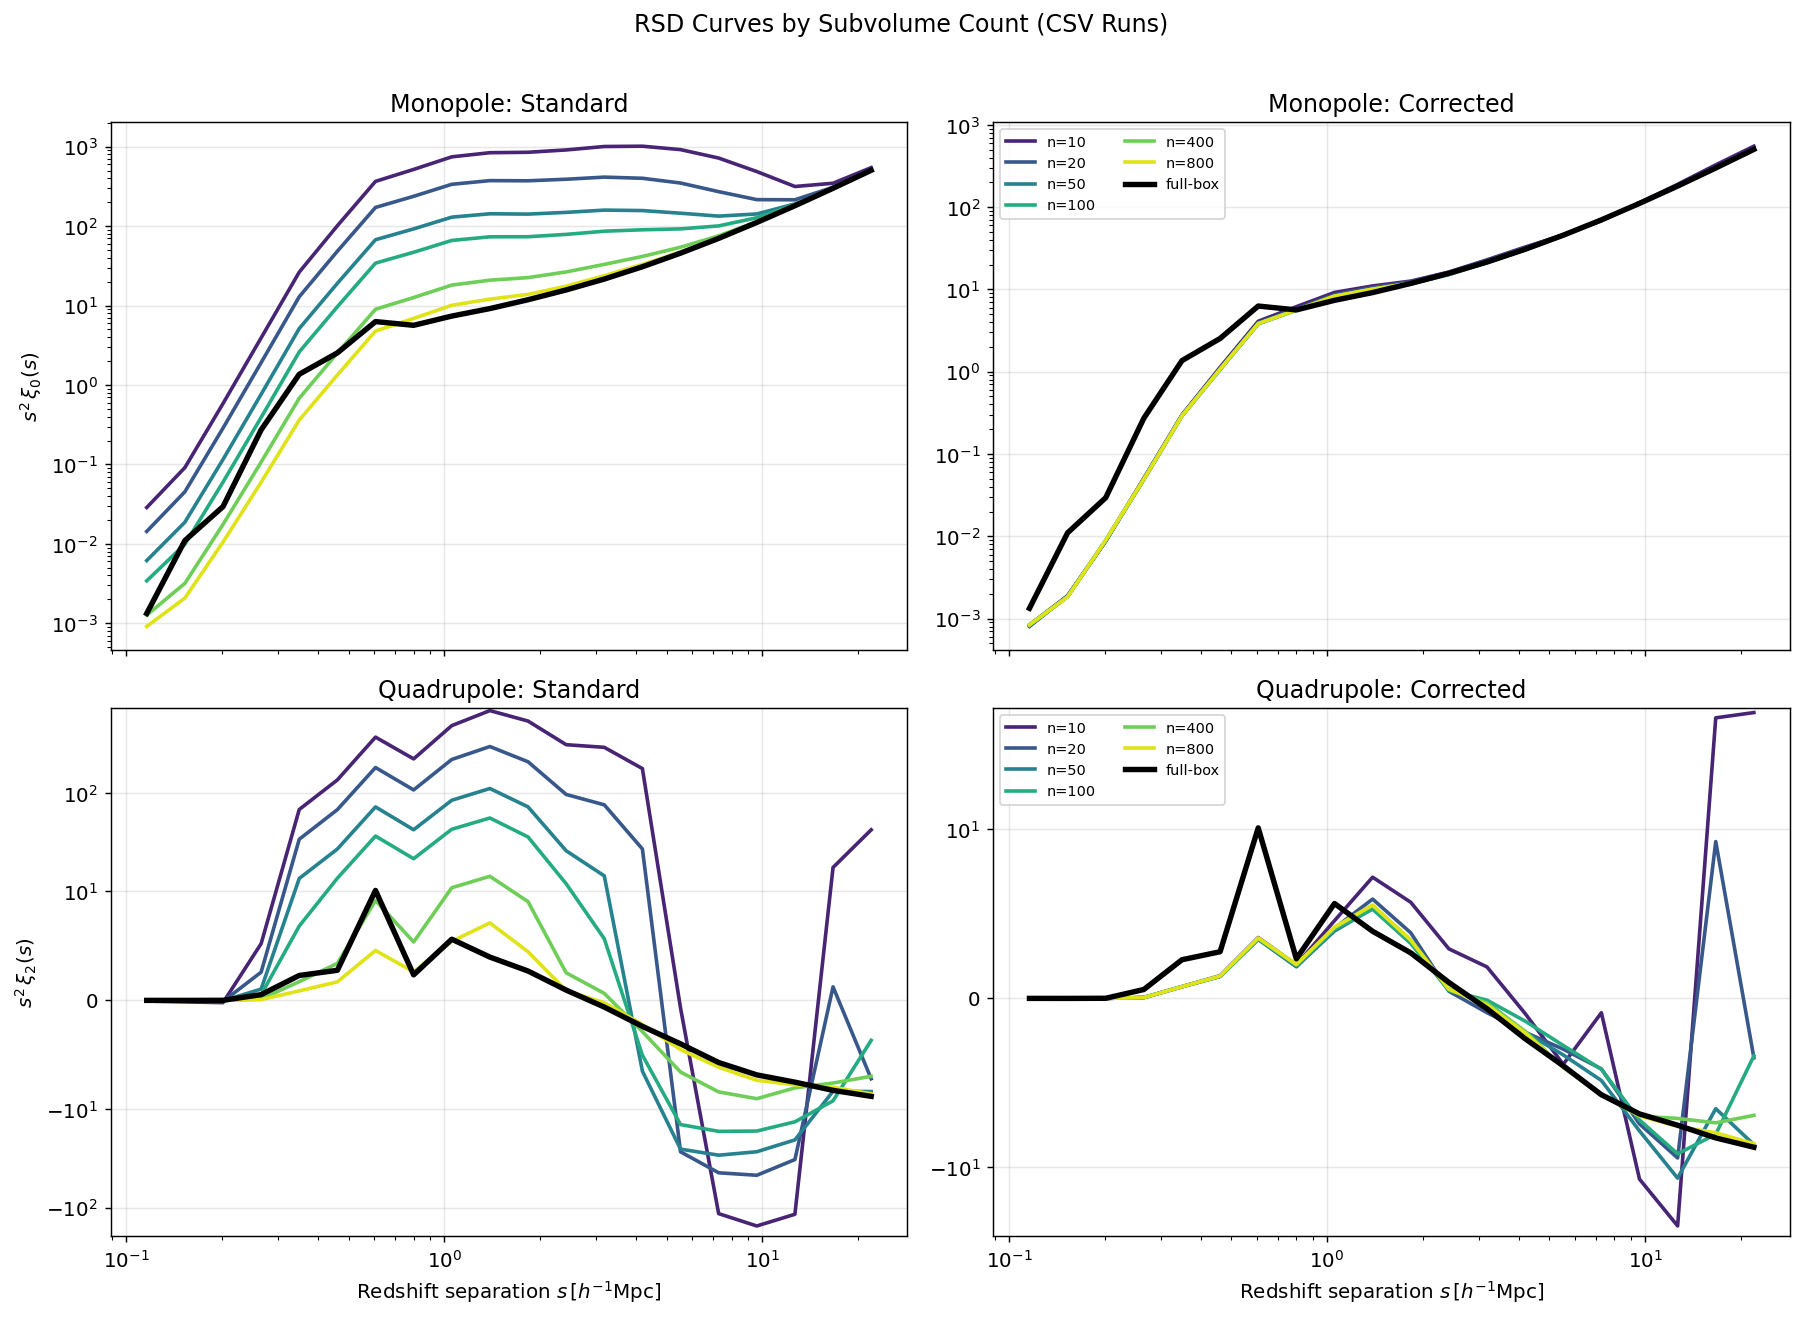

In [8]:
from glob import glob

fullbox_csv = Path("../../data/redshift_space_distortions/fullbox/lc16/L800/rsd_fullbox_standard_L800_lc16_iz155.csv")
normal_glob = "../../data/redshift_space_distortions/subvol_jobs/lc16/L800/iz155/normal/rsd_subvol_normal_L800_lc16_iz155_n*.csv"
corrected_glob = "../../data/redshift_space_distortions/subvol_jobs/lc16/L800/iz155/corrected/rsd_subvol_corrected_L800_lc16_iz155_n*.csv"

fullbox_df = pd.read_csv(fullbox_csv).sort_values("s")


def parse_nsubvol(path_str: str) -> int:
    name = Path(path_str).name
    return int(name.split("_n")[-1].replace(".csv", ""))


normal_files = sorted(glob(normal_glob), key=parse_nsubvol)
corrected_files = sorted(glob(corrected_glob), key=parse_nsubvol)

normal_by_n = {parse_nsubvol(fp): pd.read_csv(fp).sort_values("s") for fp in normal_files}
corrected_by_n = {parse_nsubvol(fp): pd.read_csv(fp).sort_values("s") for fp in corrected_files}

n_vals = sorted(set(normal_by_n).intersection(corrected_by_n))
if not n_vals:
    raise RuntimeError("No matching normal/corrected RSD CSV pairs found.")

colors = plt.cm.viridis(np.linspace(0.1, 0.95, len(n_vals)))

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
(ax_std_0, ax_cor_0), (ax_std_2, ax_cor_2) = axes

for c, n in zip(colors, n_vals):
    dfn = normal_by_n[n]
    dfc = corrected_by_n[n]

    ax_std_0.plot(dfn["s"], dfn["s"] ** 2 * dfn["xi0"], color=c, lw=2, label=f"n={n}")
    ax_cor_0.plot(dfc["s"], dfc["s"] ** 2 * dfc["xi0"], color=c, lw=2, label=f"n={n}")

    ax_std_2.plot(dfn["s"], dfn["s"] ** 2 * dfn["xi2"], color=c, lw=2, label=f"n={n}")
    ax_cor_2.plot(dfc["s"], dfc["s"] ** 2 * dfc["xi2"], color=c, lw=2, label=f"n={n}")

# Full-box reference
s_full = fullbox_df["s"].to_numpy()
ax_std_0.plot(s_full, (fullbox_df["s"] ** 2 * fullbox_df["xi0"]).to_numpy(), color="black", lw=3, label="full-box")
ax_cor_0.plot(s_full, (fullbox_df["s"] ** 2 * fullbox_df["xi0"]).to_numpy(), color="black", lw=3, label="full-box")
ax_std_2.plot(s_full, (fullbox_df["s"] ** 2 * fullbox_df["xi2"]).to_numpy(), color="black", lw=3, label="full-box")
ax_cor_2.plot(s_full, (fullbox_df["s"] ** 2 * fullbox_df["xi2"]).to_numpy(), color="black", lw=3, label="full-box")

# Axes styling
for ax in [ax_std_0, ax_cor_0, ax_std_2, ax_cor_2]:
    ax.set_xscale("log")
    ax.grid(True, alpha=0.3)

ax_std_0.set_yscale("log")
ax_cor_0.set_yscale("log")
ax_std_2.set_yscale("symlog", linthresh=10.0)
ax_cor_2.set_yscale("symlog", linthresh=10.0)

ax_std_0.set_title("Monopole: Standard")
ax_cor_0.set_title("Monopole: Corrected")
ax_std_2.set_title("Quadrupole: Standard")
ax_cor_2.set_title("Quadrupole: Corrected")

ax_std_0.set_ylabel(r"$s^2\,\xi_0(s)$")
ax_std_2.set_ylabel(r"$s^2\,\xi_2(s)$")
ax_std_2.set_xlabel(r"Redshift separation $s\,[h^{-1}\mathrm{Mpc}]$")
ax_cor_2.set_xlabel(r"Redshift separation $s\,[h^{-1}\mathrm{Mpc}]$")

ax_cor_0.legend(fontsize=8, ncol=2)
ax_cor_2.legend(fontsize=8, ncol=2)

plt.suptitle("RSD Curves by Subvolume Count (CSV Runs)", y=1.01)
plt.tight_layout()
plt.show()

## 4. Convergence To Full-Box (Standard vs Corrected)
This section compares each subvolume-run CSV against the full-box standard RSD reference.

For each mode and each $n_{subvol}$, we compute:
- median absolute fractional error in monopole $\xi_0(s)$
- median absolute fractional error in quadrupole $\xi_2(s)$

Lower values indicate better convergence to the full-box result.

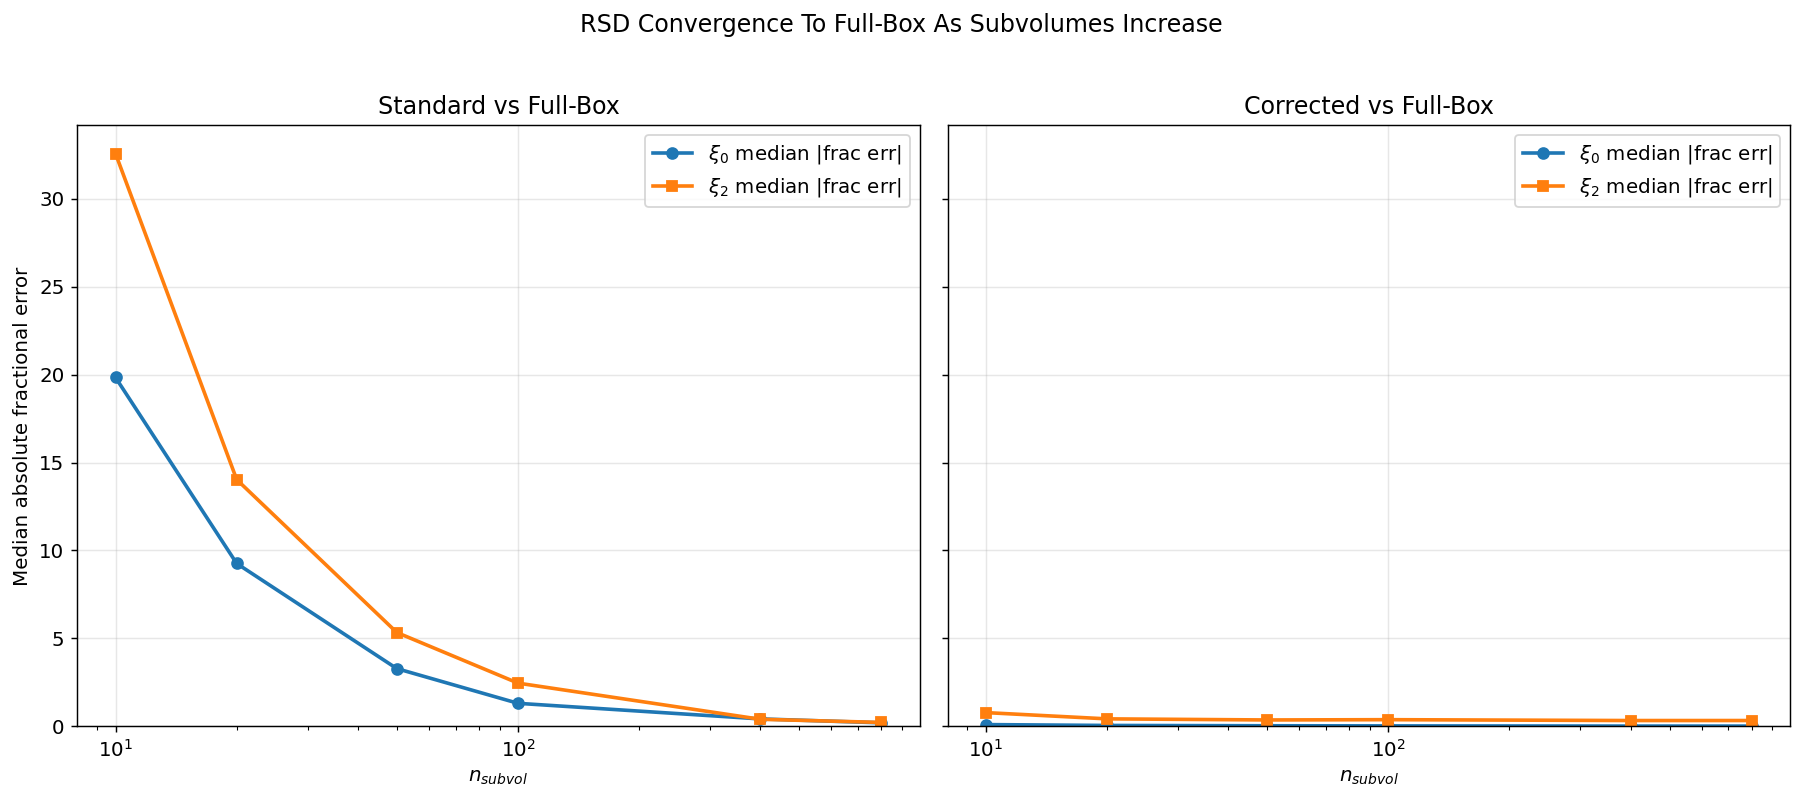

Standard convergence table:


,mode,n_subvol,med_abs_frac_xi0,med_abs_frac_xi2
0,standard,10,19.836479,32.569486
1,standard,20,9.257351,14.030859
2,standard,50,3.277481,5.330577
3,standard,100,1.303705,2.452352
4,standard,400,0.416589,0.396083
5,standard,800,0.194660,0.216692


Corrected convergence table:


,mode,n_subvol,med_abs_frac_xi0,med_abs_frac_xi2
0,corrected,10,0.093928,0.775693
1,corrected,20,0.045440,0.419733
2,corrected,50,0.027426,0.357266
3,corrected,100,0.020378,0.373423
4,corrected,400,0.009426,0.324215
5,corrected,800,0.008916,0.325164


In [7]:
from glob import glob

fullbox_path = Path("../../data/redshift_space_distortions/fullbox/lc16/L800/rsd_fullbox_standard_L800_lc16_iz155.csv")
normal_glob = "../../data/redshift_space_distortions/subvol_jobs/lc16/L800/iz155/normal/rsd_subvol_normal_L800_lc16_iz155_n*.csv"
corrected_glob = "../../data/redshift_space_distortions/subvol_jobs/lc16/L800/iz155/corrected/rsd_subvol_corrected_L800_lc16_iz155_n*.csv"

fullbox = pd.read_csv(fullbox_path).sort_values("s")


def parse_nsubvol(path_str: str) -> int:
    name = Path(path_str).name
    return int(name.split("_n")[-1].replace(".csv", ""))


def mode_convergence(files, mode_label):
    rows = []
    for fp in sorted(files, key=parse_nsubvol):
        n_sub = parse_nsubvol(fp)
        df = pd.read_csv(fp).sort_values("s")

        merged = pd.merge(
            df[["s", "xi0", "xi2"]],
            fullbox[["s", "xi0", "xi2"]],
            on="s",
            suffixes=("_run", "_full"),
            how="inner",
        )

        eps = 1e-8
        frac0 = np.abs((merged["xi0_run"] - merged["xi0_full"]) / (np.abs(merged["xi0_full"]) + eps))
        frac2 = np.abs((merged["xi2_run"] - merged["xi2_full"]) / (np.abs(merged["xi2_full"]) + eps))

        rows.append(
            {
                "mode": mode_label,
                "n_subvol": n_sub,
                "med_abs_frac_xi0": float(np.nanmedian(frac0)),
                "med_abs_frac_xi2": float(np.nanmedian(frac2)),
            }
        )

    return pd.DataFrame(rows).sort_values("n_subvol")

normal_df = mode_convergence(glob(normal_glob), "standard")
corrected_df = mode_convergence(glob(corrected_glob), "corrected")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, dfi, title in [
    (axes[0], normal_df, "Standard"),
    (axes[1], corrected_df, "Corrected"),
]:
    ax.plot(dfi["n_subvol"], dfi["med_abs_frac_xi0"], marker="o", lw=2, label=r"$\xi_0$ median |frac err|")
    ax.plot(dfi["n_subvol"], dfi["med_abs_frac_xi2"], marker="s", lw=2, label=r"$\xi_2$ median |frac err|")
    ax.set_xscale("log")
    ax.set_xlabel(r"$n_{subvol}$")
    ax.set_title(f"{title} vs Full-Box")
    ax.set_ylim(bottom=0)
    ax.legend()

axes[0].set_ylabel("Median absolute fractional error")
plt.suptitle("RSD Convergence To Full-Box As Subvolumes Increase", y=1.02)
plt.tight_layout()
plt.show()

print("Standard convergence table:")
display(normal_df)
print("Corrected convergence table:")
display(corrected_df)